In [15]:
import numpy as np

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Pick a sample image from val_ds
for images, labels in val_ds.take(1):
    img = images[0].numpy()
    label = labels[0].numpy()
    input_data = np.expand_dims(img, axis=0).astype(np.float32)

    interpreter.set_tensor(input_details[0]['index'], input_data)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])
    pred_label = np.argmax(preds[0])

print(f"True label: {label}, Predicted label: {pred_label}")


c:\Users\ROBERT\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


True label: 0, Predicted label: 0


In [14]:
#convertin to tensorflow lite
TFLITE_PATH = "warp_c_model.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f"TFLite model saved at {TFLITE_PATH}")


INFO:tensorflow:Assets written to: C:\Users\ROBERT\AppData\Local\Temp\tmp9ljdrxp8\assets


INFO:tensorflow:Assets written to: C:\Users\ROBERT\AppData\Local\Temp\tmp9ljdrxp8\assets


Saved artifact at 'C:\Users\ROBERT\AppData\Local\Temp\tmp9ljdrxp8'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2123294543312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294542928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294542544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294542352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294543888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294541200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294543504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2123294542160: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved at warp_c_model.tflite


In [13]:
# evaluating the model
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {val_acc:.4f}")


49/49 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - accuracy: 0.7421 - loss: 0.8247
Validation Accuracy: 0.7421


In [12]:
# Training the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5  #will be increased later for better accuracy
)


Epoch 1/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 650s 2s/step - accuracy: 0.7366 - loss: 0.8708 - val_accuracy: 0.7228 - val_loss: 0.8403
Epoch 2/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 322s 1s/step - accuracy: 0.7533 - loss: 0.7173 - val_accuracy: 0.7344 - val_loss: 0.7869
Epoch 3/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 252s 913ms/step - accuracy: 0.7707 - loss: 0.6414 - val_accuracy: 0.7434 - val_loss: 0.7220
Epoch 4/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 257s 931ms/step - accuracy: 0.7994 - loss: 0.5452 - val_accuracy: 0.7427 - val_loss: 0.7518
Epoch 5/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 271s 981ms/step - accuracy: 0.8414 - loss: 0.4228 - val_accuracy: 0.7421 - val_loss: 0.8247


In [11]:
# compiling the model 
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])


c:\Users\ROBERT\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
train_ds = train_ds_raw.map(lambda x, y: (x/255.0, y))
val_ds = val_ds_raw.map(lambda x, y: (x/255.0, y))


In [8]:
# Load dataset WITHOUT normalization first to get class names
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Warp-C/train_crops",
    image_size=(128, 128),
    batch_size=32
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "Warp-C/test_crops",
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds_raw.class_names
print("Classes:", class_names)
num_classes = len(class_names)


Found 8823 files belonging to 5 classes.
Found 1551 files belonging to 5 classes.
Classes: ['bottle', 'canister', 'cans', 'cardboard', 'detergent']


In [7]:
train_ds = train_ds.map(lambda x, y: (x/255.0, y))
val_ds = val_ds.map(lambda x, y: (x/255.0, y))


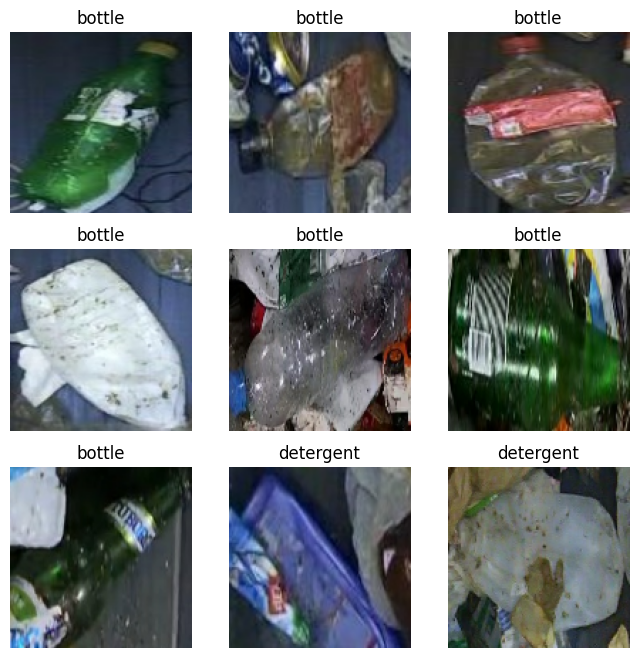

In [6]:
import matplotlib.pyplot as plt

# Show 9 images from the training set
plt.figure(figsize=(8,8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")
plt.show()


In [5]:
import tensorflow as tf

train_dir = "Warp-C/train_crops"
val_dir   = "Warp-C/test_crops"

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(128, 128),   # small for Edge AI
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(128, 128),
    batch_size=32
)

# Check class names
print("Classes:", train_ds.class_names)


Found 8823 files belonging to 5 classes.
Found 1551 files belonging to 5 classes.
Classes: ['bottle', 'canister', 'cans', 'cardboard', 'detergent']


In [4]:
import os
print(os.listdir("Warp-C"))


['Classification.md', 'move.sh', 'test_crops', 'train_crops']


In [3]:
import os
print(os.listdir())


['.idea', 'archive.zip', 'assets', 'README.md', 'Warp-C', 'Warp-D', 'warp-recycling-waste.ipynb', 'Warp-S', 'warp-waste-recycling-plant-dataset-metadata.json']
